Problem 01: Data Exploration and preprocessing
I
nstalling the modules.

In [3]:

!pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from datasets import load_dataset
from torchvision import transforms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 10.7 MB/s  0:00:00

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Loading the dataset and reporting its size and structure

In [10]:
from datasets import load_dataset
import numpy as np

# Load dataset
ds = load_dataset("nikolkoo/SatelliteSegmentation")
full_ds = ds["train"]

print("Available splits:", ds.keys())
print("Number of samples:", len(full_ds))
print("Column names:", full_ds.column_names)

# Inspect one sample
sample0 = full_ds[0]
img0 = sample0["image"]
mask0 = sample0["mask"]

print("Image type:", type(img0))
print("Mask type:", type(mask0))
print("Image size (width, height):", img0.size)
print("Mask size (width, height):", mask0.size)

# Find all unique class values in the masks
all_unique = set()
for i in range(len(full_ds)):
    mask_arr = np.array(full_ds[i]["mask"])
    all_unique.update(np.unique(mask_arr).tolist())

original_classes = sorted(all_unique)
num_classes = len(original_classes)

print("Original mask values:", original_classes)
print("Number of classes:", num_classes)

Available splits: dict_keys(['train'])
Number of samples: 790
Column names: ['image', 'mask']
Image type: <class 'PIL.PngImagePlugin.PngImageFile'>
Mask type: <class 'PIL.PngImagePlugin.PngImageFile'>
Image size (width, height): (256, 256)
Mask size (width, height): (256, 256)
Original mask values: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
Number of classes: 11


Visualizing image-mask pairs:


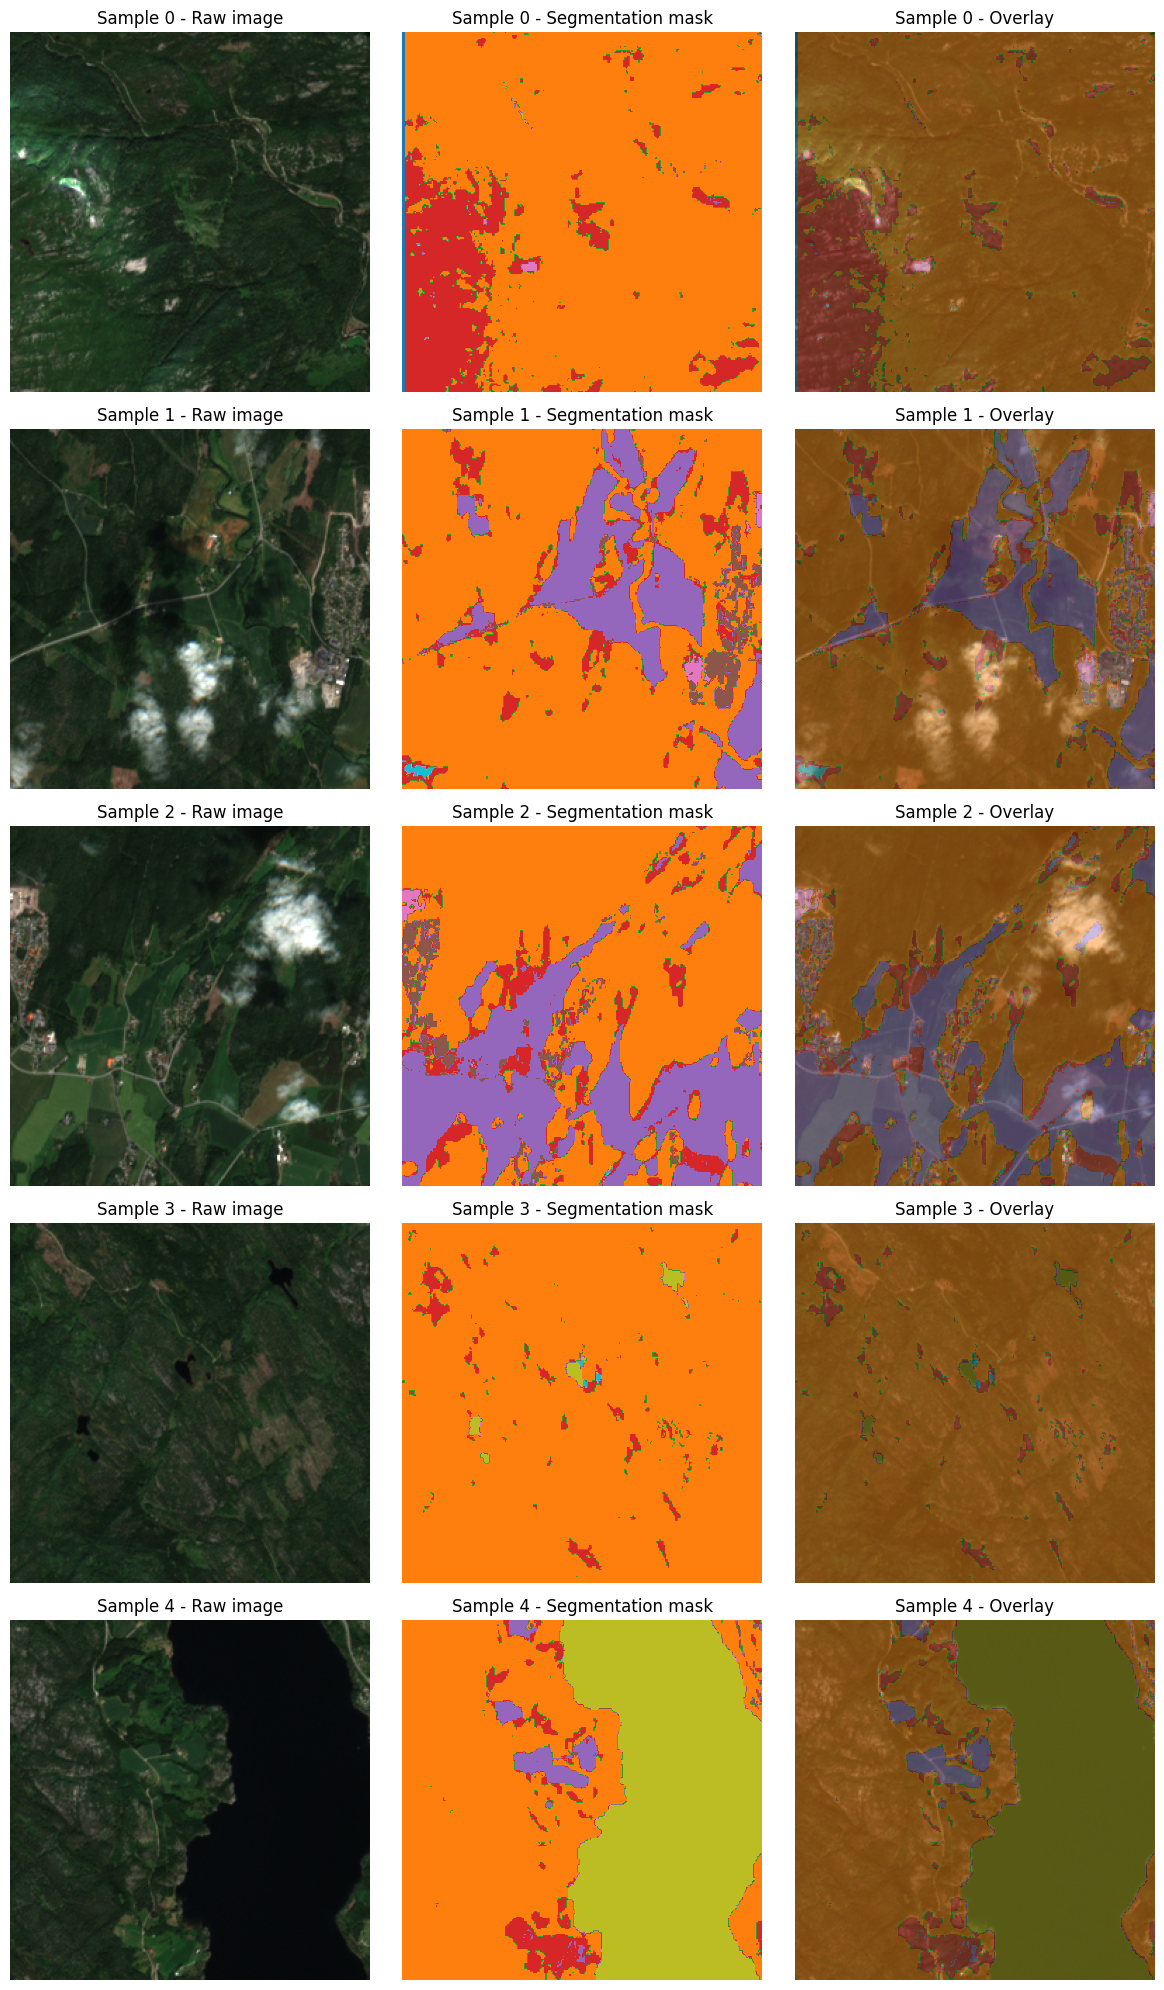

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Build class mapping
class_map = {v: i for i, v in enumerate(original_classes)}
inverse_class_map = {i: v for v, i in class_map.items()}

def remap_mask(mask_pil, class_map):
    mask = np.array(mask_pil)
    remapped = np.zeros_like(mask, dtype=np.int64)
    for old_val, new_val in class_map.items():
        remapped[mask == old_val] = new_val
    return remapped

# Consistent colormap
cmap = plt.get_cmap("tab10", num_classes)

# Show 5 samples: raw image, raw mask, overlay
num_to_show = 5
fig, axes = plt.subplots(num_to_show, 3, figsize=(12, 4 * num_to_show))

for i in range(num_to_show):
    sample = full_ds[i]
    image = np.array(sample["image"])
    mask_remapped = remap_mask(sample["mask"], class_map)

    # Raw image
    axes[i, 0].imshow(image)
    axes[i, 0].set_title(f"Sample {i} - Raw image")
    axes[i, 0].axis("off")

    # Mask
    axes[i, 1].imshow(mask_remapped, cmap=cmap, vmin=0, vmax=num_classes - 1)
    axes[i, 1].set_title(f"Sample {i} - Segmentation mask")
    axes[i, 1].axis("off")

    # Overlay
    axes[i, 2].imshow(image)
    axes[i, 2].imshow(mask_remapped, cmap=cmap, alpha=0.45, vmin=0, vmax=num_classes - 1)
    axes[i, 2].set_title(f"Sample {i} - Overlay")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

Compute and plot class balance:


    class_index  original_mask_value  pixel_count      fraction
0             0                    0        10752  2.076741e-04
1             1                   10     36560738  7.061678e-01
2             2                   20         1626  3.140606e-05
3             3                   30      4801317  9.273707e-02
4             4                   40      3821687  7.381559e-02
5             5                   50      1955765  3.777545e-02
6             6                   60        92350  1.783733e-03
7             7                   70           49  9.464312e-07
8             8                   80      4456426  8.607552e-02
9             9                   90        40555  7.833167e-04
10           10                  100        32175  6.214576e-04


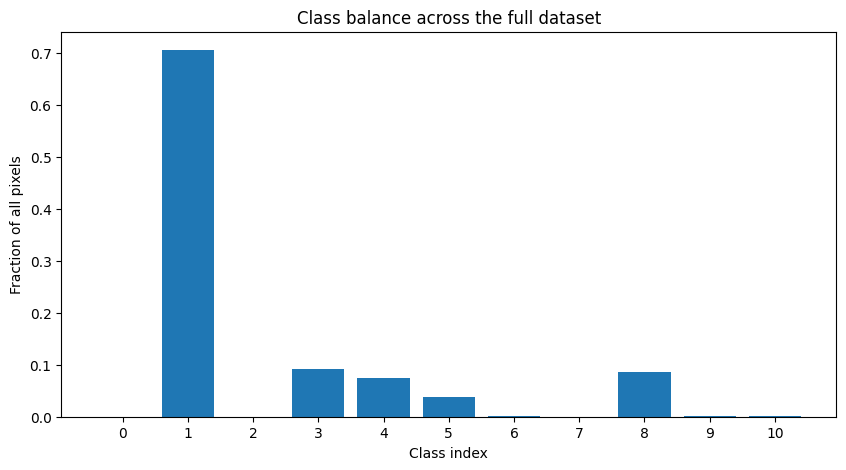

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pixel_counts = np.zeros(num_classes, dtype=np.int64)

for i in range(len(full_ds)):
    mask_remapped = remap_mask(full_ds[i]["mask"], class_map)
    vals, counts = np.unique(mask_remapped, return_counts=True)
    pixel_counts[vals] += counts

total_pixels = pixel_counts.sum()
class_fractions = pixel_counts / total_pixels

class_balance_df = pd.DataFrame({
    "class_index": np.arange(num_classes),
    "original_mask_value": [inverse_class_map[i] for i in range(num_classes)],
    "pixel_count": pixel_counts,
    "fraction": class_fractions
})

print(class_balance_df)

plt.figure(figsize=(10, 5))
plt.bar(class_balance_df["class_index"].astype(str), class_balance_df["fraction"])
plt.xlabel("Class index")
plt.ylabel("Fraction of all pixels")
plt.title("Class balance across the full dataset")
plt.show()

The class distribution is imbalanced. Class 1 has the largest fraction (0.7062), while class 7 has the smallest fraction (0.0000). This imbalance can make the classifier biased toward dominant classes and reduce performance on minority classes.

Buildiing Pytorch Dataset and Dataloader:


In [14]:
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.transforms import InterpolationMode
import numpy as np

TARGET_SIZE = (256, 256)   # divisible by 8

class SatelliteSegDataset(Dataset):
    def __init__(self, hf_dataset, class_map, target_size=(256, 256)):
        self.ds = hf_dataset
        self.class_map = class_map
        self.target_size = target_size

        self.img_transform = transforms.Compose([
            transforms.Resize(target_size, interpolation=InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        sample = self.ds[idx]
        image = sample["image"]
        mask = sample["mask"]

        # Image -> float32 tensor (3,H,W)
        image_tensor = self.img_transform(image).to(torch.float32)

        # Remap mask values to 0..C-1
        mask_np = np.array(mask)
        remapped = np.zeros_like(mask_np, dtype=np.int64)
        for old_val, new_val in self.class_map.items():
            remapped[mask_np == old_val] = new_val

        # Resize mask with nearest neighbor
        remapped_pil = Image.fromarray(remapped.astype(np.uint8))
        remapped_pil = remapped_pil.resize(
            (self.target_size[1], self.target_size[0]),
            resample=Image.NEAREST
        )

        mask_tensor = torch.tensor(np.array(remapped_pil), dtype=torch.int64)

        return image_tensor, mask_tensor

# Build processed dataset
processed_ds = SatelliteSegDataset(full_ds, class_map=class_map, target_size=TARGET_SIZE)

# Split 80/20
train_size = int(0.8 * len(processed_ds))
val_size = len(processed_ds) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(processed_ds, [train_size, val_size], generator=generator)

# Create DataLoaders
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# Check one batch
images_batch, masks_batch = next(iter(train_loader))

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Images batch shape:", images_batch.shape)   # (B,3,H,W)
print("Masks batch shape:", masks_batch.shape)     # (B,H,W)
print("Images dtype:", images_batch.dtype)
print("Masks dtype:", masks_batch.dtype)
print("Mask min/max:", masks_batch.min().item(), masks_batch.max().item())

Train size: 632
Validation size: 158
Images batch shape: torch.Size([8, 3, 256, 256])
Masks batch shape: torch.Size([8, 256, 256])
Images dtype: torch.float32
Masks dtype: torch.int64
Mask min/max: 1 9


Problem 2: Model design and implementation:


Defining a convolutional segmentation model

In [15]:
import torch
import torch.nn as nn

# -------------------------
# Basic conv block
# -------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

# -------------------------
# U-Net style model
# -------------------------
class UNetSmall(nn.Module):
    def __init__(self, in_channels=3, num_classes=9):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        # Decoder
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        # Final output layer
        self.final_conv = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)          # (B,32,H,W)
        p1 = self.pool1(e1)        # (B,32,H/2,W/2)

        e2 = self.enc2(p1)         # (B,64,H/2,W/2)
        p2 = self.pool2(e2)        # (B,64,H/4,W/4)

        e3 = self.enc3(p2)         # (B,128,H/4,W/4)
        p3 = self.pool3(e3)        # (B,128,H/8,W/8)

        # Bottleneck
        b = self.bottleneck(p3)    # (B,256,H/8,W/8)

        # Decoder + skip connections
        u3 = self.up3(b)           # (B,128,H/4,W/4)
        u3 = torch.cat([u3, e3], dim=1)
        d3 = self.dec3(u3)         # (B,128,H/4,W/4)

        u2 = self.up2(d3)          # (B,64,H/2,W/2)
        u2 = torch.cat([u2, e2], dim=1)
        d2 = self.dec2(u2)         # (B,64,H/2,W/2)

        u1 = self.up1(d2)          # (B,32,H,W)
        u1 = torch.cat([u1, e1], dim=1)
        d1 = self.dec1(u1)         # (B,32,H,W)

        # Per-pixel logits
        out = self.final_conv(d1)  # (B,C,H,W)

        return out

Verifying the model:

In [16]:
# number of classes from your masks
num_classes = 9

model = UNetSmall(in_channels=3, num_classes=num_classes)

# dummy batch
x = torch.randn(4, 3, 256, 256)   # (B,3,H,W)
y = model(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)

Input shape : torch.Size([4, 3, 256, 256])
Output shape: torch.Size([4, 9, 256, 256])


Reporting the total number of trainable parameters:

In [17]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_trainable_params(model)
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 1,925,865


I selected a U-Net style encoder-decoder architecture because semantic segmentation requires pixel-level prediction rather than a single image-level class. Unlike a standard classification CNN, this model preserves spatial structure throughout the network and outputs a class score for every pixel. The skip connections help recover fine spatial details by passing high-resolution encoder features directly to the decoder, which is especially useful for boundaries and small objects. Because the model is fully convolutional, it can process image batches of shape (B, 3, H, W) and produce dense output tensors of shape (B, C, H, W).

testing the model:

In [18]:
images_batch, masks_batch = next(iter(train_loader))

print("Batch image shape:", images_batch.shape)
print("Batch mask shape :", masks_batch.shape)

outputs = model(images_batch)

print("Model output shape:", outputs.shape)

Batch image shape: torch.Size([8, 3, 256, 256])
Batch mask shape : torch.Size([8, 256, 256])
Model output shape: torch.Size([8, 9, 256, 256])


Problem 3: Training

Computing inverse-frquency class weights

In [20]:
import torch
import numpy as np

# Compute class counts from the processed dataset
all_labels = set()
class_pixel_counts = None

for i in range(len(processed_ds)):
    _, mask = processed_ds[i]
    unique_vals, counts = torch.unique(mask, return_counts=True)

    if class_pixel_counts is None:
        num_classes = int(torch.max(mask).item()) + 1
        class_pixel_counts = torch.zeros(num_classes, dtype=torch.long)

    for val, cnt in zip(unique_vals, counts):
        class_pixel_counts[val.item()] += cnt.item()
        all_labels.add(val.item())

num_classes = len(sorted(all_labels))
total_pixels = class_pixel_counts.sum().item()

print("Classes found:", sorted(all_labels))
print("Number of classes:", num_classes)
print("Pixel counts per class:", class_pixel_counts.tolist())
print("Total pixels:", total_pixels)

# Inverse-frequency weights
class_weights = total_pixels / (num_classes * class_pixel_counts.float())

print("Class weights:", class_weights)

Classes found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Number of classes: 11
Pixel counts per class: [10752, 36560738, 1626, 4801317, 3821687, 1955765, 92350, 49, 4456426, 40555, 32175]
Total pixels: 51773440
Class weights: tensor([4.3775e+02, 1.2874e-01, 2.8946e+03, 9.8029e-01, 1.2316e+00, 2.4066e+00,
        5.0966e+01, 9.6055e+04, 1.0562e+00, 1.1606e+02, 1.4628e+02])


Defining model, loss, optimizer and scheduler

In [21]:
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Build model with correct number of classes
model = UNetSmall(in_channels=3, num_classes=num_classes).to(device)

# Weighted cross-entropy loss
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Optional scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

# Quick sanity check
images_batch, masks_batch = next(iter(train_loader))
images_batch = images_batch.to(device)
masks_batch = masks_batch.to(device)

outputs = model(images_batch)
print("Output shape:", outputs.shape)
print("Mask shape:", masks_batch.shape)
print("Mask unique values:", torch.unique(masks_batch))

loss = criterion(outputs, masks_batch)
print("Initial loss:", loss.item())

Using device: cpu
Output shape: torch.Size([8, 11, 256, 256])
Mask shape: torch.Size([8, 256, 256])
Mask unique values: tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
Initial loss: 2.3792200088500977


Defining loU function

In [22]:
def compute_mean_iou(preds, targets, num_classes):
    """
    preds: (B,H,W) predicted class indices
    targets: (B,H,W) ground-truth class indices
    """
    ious = []

    for cls in range(num_classes):
        pred_cls = (preds == cls)
        target_cls = (targets == cls)

        intersection = (pred_cls & target_cls).sum().item()
        union = (pred_cls | target_cls).sum().item()

        if union == 0:
            continue  # skip class if absent in both pred and target

        iou = intersection / union
        ious.append(iou)

    if len(ious) == 0:
        return 0.0

    return sum(ious) / len(ious)

Model training and validation loop for 20 epochs

In [23]:
num_epochs = 20

train_losses = []
val_losses = []
val_ious = []

for epoch in range(num_epochs):
    # -------------------
    # Training
    # -------------------
    model.train()
    running_train_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # -------------------
    # Validation
    # -------------------
    model.eval()
    running_val_loss = 0.0
    batch_ious = []

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_val_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            iou = compute_mean_iou(preds, masks, num_classes)
            batch_ious.append(iou)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_iou = sum(batch_ious) / len(batch_ious)

    val_losses.append(epoch_val_loss)
    val_ious.append(epoch_val_iou)

    # Step scheduler
    scheduler.step(epoch_val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val mIoU: {epoch_val_iou:.4f}"
    )

Epoch [1/20] | Train Loss: 2.2024 | Val Loss: 2.0349 | Val mIoU: 0.1074
Epoch [2/20] | Train Loss: 1.7561 | Val Loss: 1.7829 | Val mIoU: 0.1134
Epoch [3/20] | Train Loss: 1.5874 | Val Loss: 1.6545 | Val mIoU: 0.1637
Epoch [4/20] | Train Loss: 1.4700 | Val Loss: 1.7978 | Val mIoU: 0.0906
Epoch [5/20] | Train Loss: 1.4322 | Val Loss: 1.5759 | Val mIoU: 0.2165
Epoch [6/20] | Train Loss: 1.3363 | Val Loss: 2.2676 | Val mIoU: 0.0339
Epoch [7/20] | Train Loss: 1.3626 | Val Loss: 1.3831 | Val mIoU: 0.2275
Epoch [8/20] | Train Loss: 1.2336 | Val Loss: 1.3550 | Val mIoU: 0.1801
Epoch [9/20] | Train Loss: 1.2174 | Val Loss: 1.4299 | Val mIoU: 0.2345
Epoch [10/20] | Train Loss: 1.1666 | Val Loss: 1.3316 | Val mIoU: 0.2287
Epoch [11/20] | Train Loss: 1.1699 | Val Loss: 1.3017 | Val mIoU: 0.2421
Epoch [12/20] | Train Loss: 1.1392 | Val Loss: 1.3372 | Val mIoU: 0.1748
Epoch [13/20] | Train Loss: 1.1479 | Val Loss: 1.2547 | Val mIoU: 0.2120
Epoch [14/20] | Train Loss: 1.1267 | Val Loss: 1.1948 | Val 

Plottoing

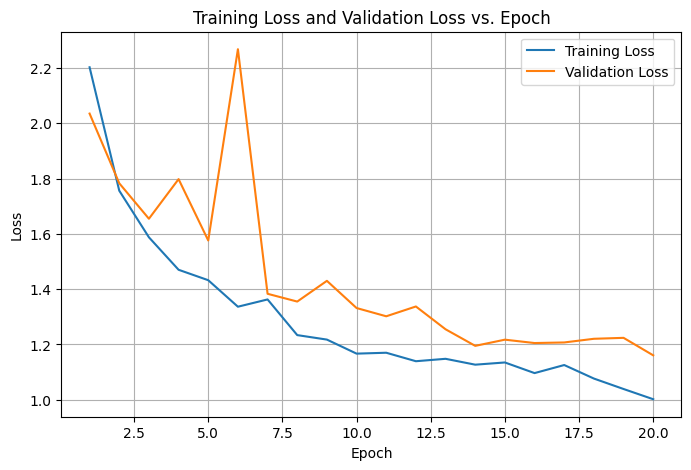

In [24]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Training Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss and Validation Loss vs. Epoch")
plt.legend()
plt.grid(True)
plt.show()

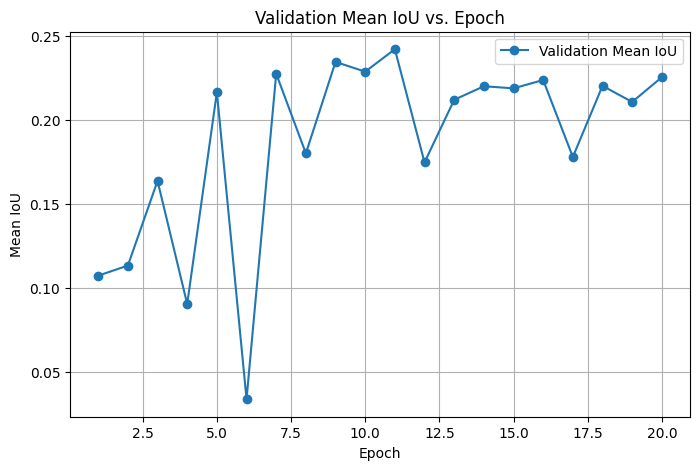

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, val_ious, marker="o", label="Validation Mean IoU")
plt.xlabel("Epoch")
plt.ylabel("Mean IoU")
plt.title("Validation Mean IoU vs. Epoch")
plt.legend()
plt.grid(True)
plt.show()

The model does not show strong evidence of overfitting. Both the training and validation losses decrease over the epochs, and although the validation loss is consistently higher than the training loss, the gap remains relatively stable rather than widening significantly. This suggests that the model is learning generalizable features rather than memorizing the training data.

The validation mean IoU shows an overall increasing trend, improving from around 0.10 in early epochs to approximately 0.22–0.24 in later epochs, despite some fluctuations. These fluctuations indicate variability in performance across batches or class imbalance, but the upward trend confirms that the model continues to improve on unseen data.

Overall, the model demonstrates reasonable generalization, with no clear signs of severe overfitting. However, the relatively low IoU values suggest that there is still room for improvement, possibly through better architecture tuning, longer training, or enhanced handling of class imbalance.

Problem 04: Quantitative evaluation

4a.1 mloU

In [27]:
import torch
import numpy as np

def evaluate_iou_full(model, val_loader, num_classes, device):
    model.eval()

    # confusion stats
    tp = np.zeros(num_classes, dtype=np.int64)
    fp = np.zeros(num_classes, dtype=np.int64)
    fn = np.zeros(num_classes, dtype=np.int64)

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            for c in range(num_classes):
                pred_c = (preds == c)
                mask_c = (masks == c)

                tp[c] += (pred_c & mask_c).sum().item()
                fp[c] += (pred_c & ~mask_c).sum().item()
                fn[c] += (~pred_c & mask_c).sum().item()

    iou_per_class = np.zeros(num_classes, dtype=np.float64)

    for c in range(num_classes):
        denom = tp[c] + fp[c] + fn[c]
        if denom == 0:
            iou_per_class[c] = np.nan
        else:
            iou_per_class[c] = tp[c] / denom

    mean_iou = np.nanmean(iou_per_class)

    return mean_iou, iou_per_class, tp, fp, fn

mean_iou, iou_per_class, tp, fp, fn = evaluate_iou_full(
    model, val_loader, num_classes, device
)

print("Mean IoU:", mean_iou)
print("Per-class IoU:", iou_per_class)

Mean IoU: 0.2229670673360135
Per-class IoU: [1.91519758e-02 6.45006067e-01 0.00000000e+00 2.61812822e-01
 2.78467627e-01 3.48229319e-01 8.85796010e-02 1.41368066e-05
 7.74891571e-01 4.89215931e-03 3.15924614e-02]


4a.2 Per class loU bar chart

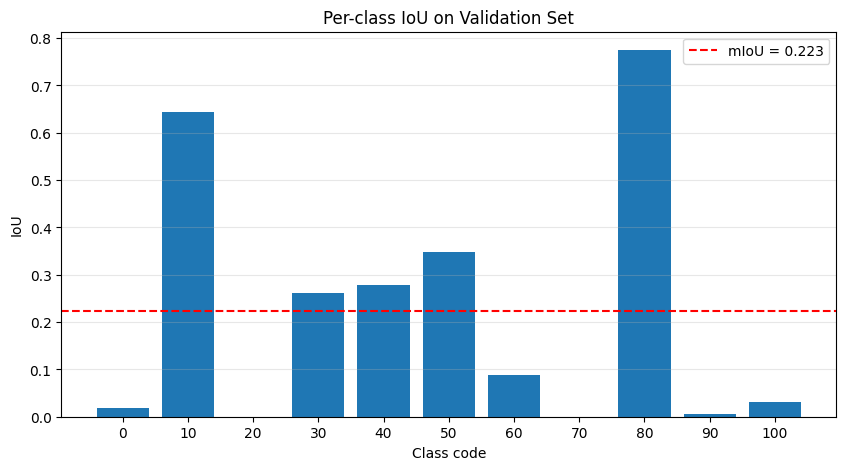

In [28]:
import matplotlib.pyplot as plt
import numpy as np

class_labels = [str(inverse_class_map[i]) for i in range(num_classes)]

plt.figure(figsize=(10, 5))
plt.bar(class_labels, iou_per_class)
plt.axhline(mean_iou, color="red", linestyle="--", label=f"mIoU = {mean_iou:.3f}")

plt.xlabel("Class code")
plt.ylabel("IoU")
plt.title("Per-class IoU on Validation Set")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

In [29]:
import pandas as pd

iou_table = pd.DataFrame({
    "class_index": list(range(num_classes)),
    "class_code": [inverse_class_map[i] for i in range(num_classes)],
    "IoU": iou_per_class,
    "pixel_fraction": class_fractions
})

print(iou_table.sort_values("IoU"))

    class_index  class_code       IoU  pixel_fraction
2             2          20  0.000000    3.140606e-05
7             7          70  0.000014    9.464312e-07
9             9          90  0.004892    7.833167e-04
0             0           0  0.019152    2.076741e-04
10           10         100  0.031592    6.214576e-04
6             6          60  0.088580    1.783733e-03
3             3          30  0.261813    9.273707e-02
4             4          40  0.278468    7.381559e-02
5             5          50  0.348229    3.777545e-02
1             1          10  0.645006    7.061678e-01
8             8          80  0.774892    8.607552e-02


4a.3

The model exhibits highly uneven performance across classes, with strong performance on dominant classes and very poor performance on rare ones. Classes 10 and 80 achieve the highest IoU scores (≈0.65 and ≈0.77), which aligns with their large pixel fractions (≈70.6% and ≈8.6%, respectively). In contrast, several classes such as 20, 70, and 90 have near-zero IoU, corresponding to extremely small pixel fractions, indicating that the model fails to learn meaningful representations for these rare classes. This clearly demonstrates a strong correlation between class frequency and model performance. Classes with more training pixels provide stronger learning signals, while rare classes are underrepresented and often ignored by the model despite the use of class weighting. Even moderately represented classes (e.g., 30, 40, 50) achieve only moderate IoU values, suggesting that the model still struggles with boundary precision and inter-class confusion. Therefore, the results highlight that class imbalance is a major limiting factor in segmentation performance. The model is biased toward dominant land-cover types and has difficulty capturing fine-scale or infrequent patterns. This suggests that further improvements could be achieved through techniques such as stronger class rebalancing, focal loss, data augmentation, or architectural enhancements to better capture minority classes.

4b


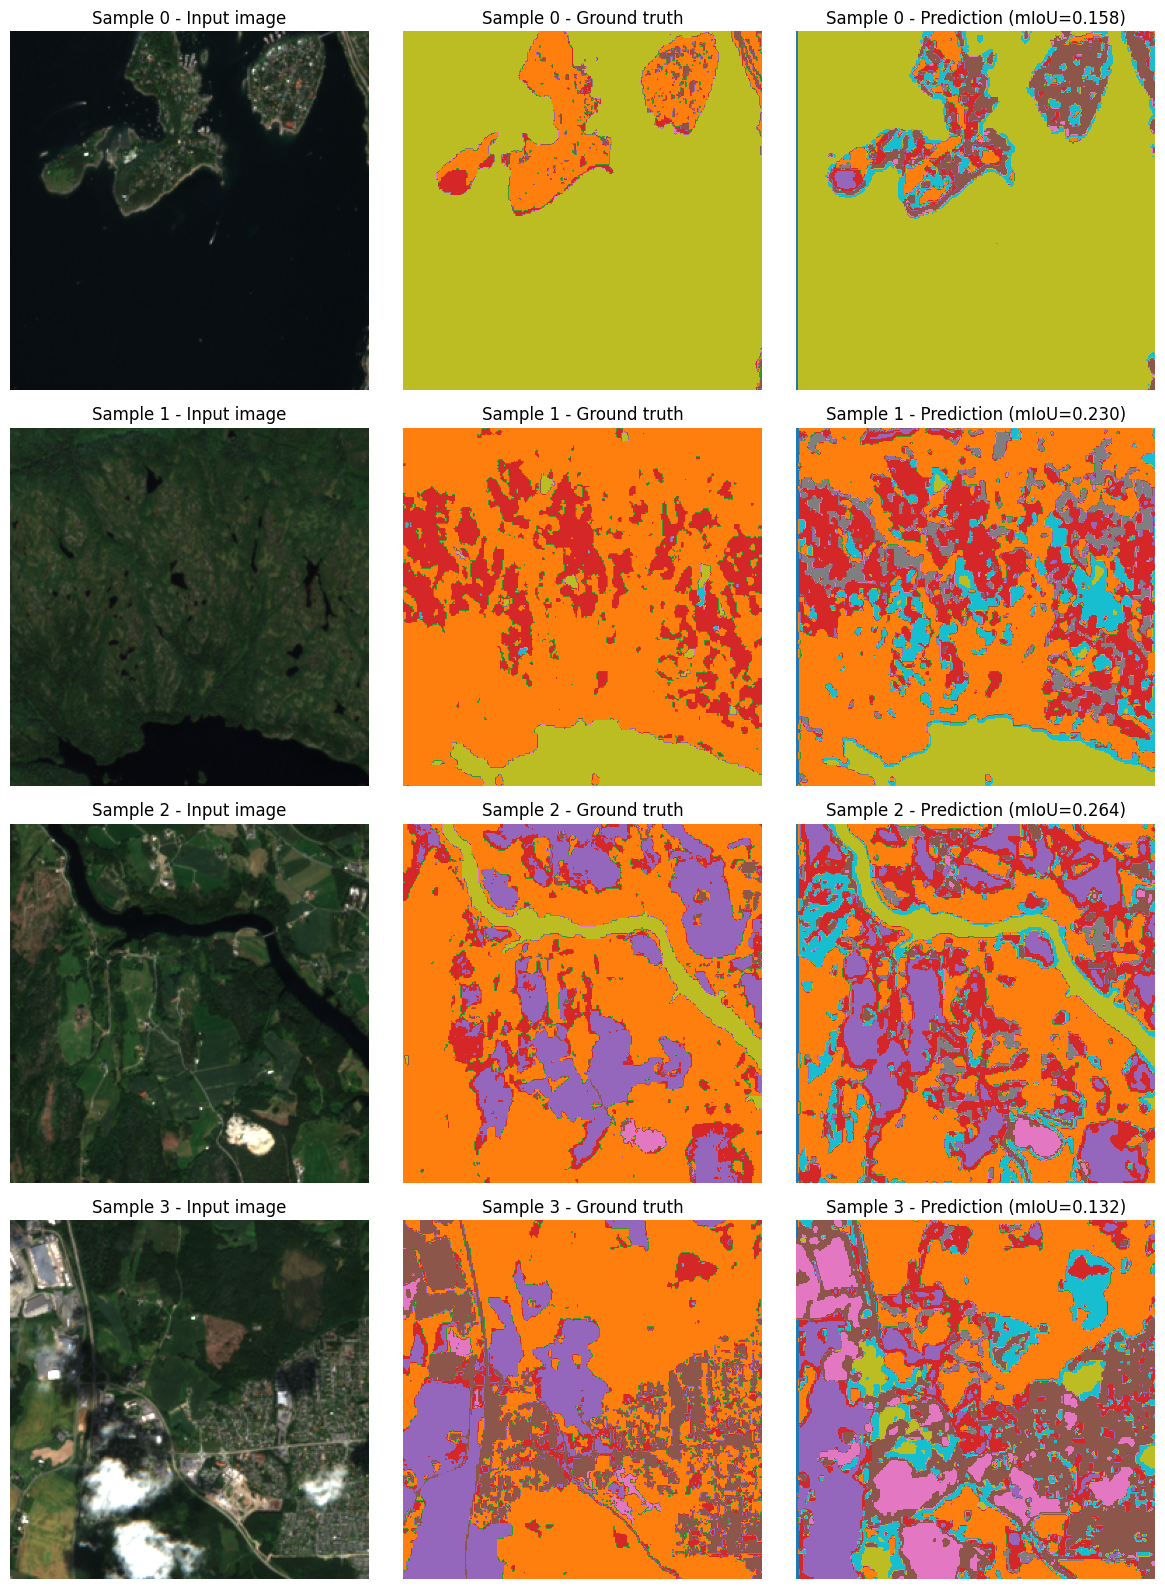

In [30]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# undo normalization for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def compute_sample_iou(pred_mask, true_mask, num_classes):
    ious = []
    for c in range(num_classes):
        pred_c = (pred_mask == c)
        true_c = (true_mask == c)

        intersection = (pred_c & true_c).sum().item()
        union = (pred_c | true_c).sum().item()

        if union == 0:
            continue

        ious.append(intersection / union)

    if len(ious) == 0:
        return 0.0
    return sum(ious) / len(ious)

model.eval()

num_show = 4
shown = 0

fig, axes = plt.subplots(num_show, 3, figsize=(12, 4 * num_show))

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        for b in range(images.size(0)):
            if shown >= num_show:
                break

            img = images[b].cpu() * std + mean
            img = img.clamp(0, 1).permute(1, 2, 0).numpy()

            true_mask = masks[b].cpu().numpy()
            pred_mask = preds[b].cpu().numpy()

            sample_iou = compute_sample_iou(
                torch.tensor(pred_mask),
                torch.tensor(true_mask),
                num_classes
            )

            axes[shown, 0].imshow(img)
            axes[shown, 0].set_title(f"Sample {shown} - Input image")
            axes[shown, 0].axis("off")

            axes[shown, 1].imshow(true_mask, cmap=cmap, vmin=0, vmax=num_classes - 1)
            axes[shown, 1].set_title(f"Sample {shown} - Ground truth")
            axes[shown, 1].axis("off")

            axes[shown, 2].imshow(pred_mask, cmap=cmap, vmin=0, vmax=num_classes - 1)
            axes[shown, 2].set_title(f"Sample {shown} - Prediction (mIoU={sample_iou:.3f})")
            axes[shown, 2].axis("off")

            shown += 1

        if shown >= num_show:
            break

plt.tight_layout()
plt.show()

4b.2

In [31]:
sample_results = []

model.eval()
idx_counter = 0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        for b in range(images.size(0)):
            sample_iou = compute_sample_iou(preds[b], masks[b], num_classes)
            sample_results.append((idx_counter, sample_iou, images[b].cpu(), masks[b].cpu(), preds[b].cpu()))
            idx_counter += 1

sample_results_sorted = sorted(sample_results, key=lambda x: x[1])

worst_sample = sample_results_sorted[0]
best_sample = sample_results_sorted[-1]

print("Worst sample IoU:", worst_sample[1])
print("Best sample IoU :", best_sample[1])

Worst sample IoU: 0.04297413931780088
Best sample IoU : 0.29919656221446755


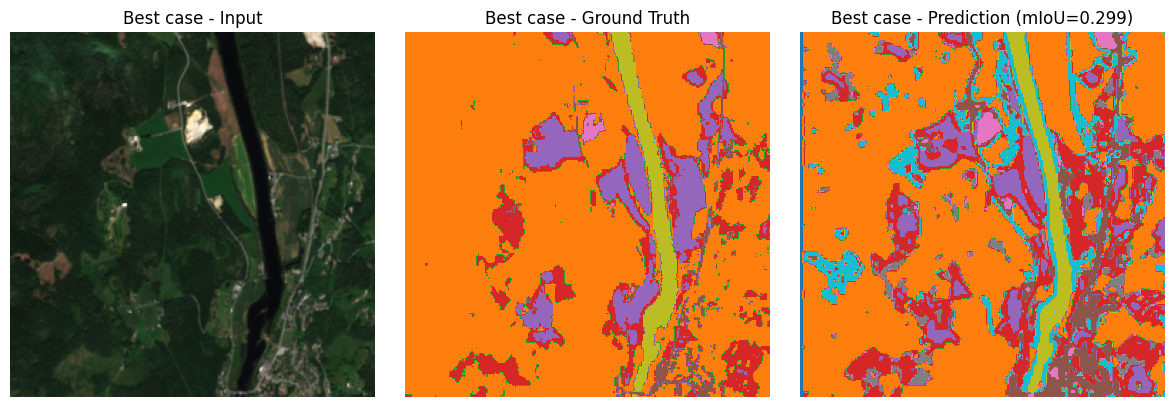

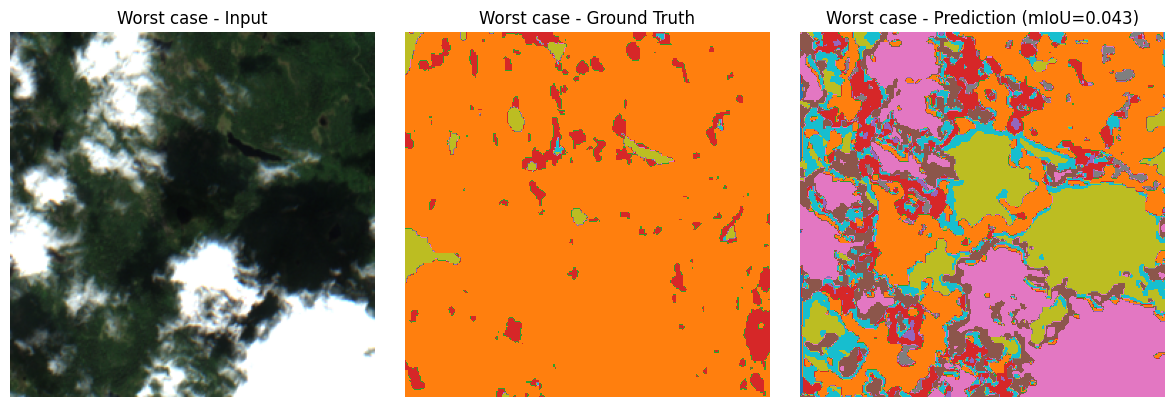

In [32]:
def show_single_case(sample_tuple, title_prefix):
    idx, sample_iou, image_t, true_mask_t, pred_mask_t = sample_tuple

    img = image_t * std + mean
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()

    true_mask = true_mask_t.numpy()
    pred_mask = pred_mask_t.numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img)
    axes[0].set_title(f"{title_prefix} - Input")
    axes[0].axis("off")

    axes[1].imshow(true_mask, cmap=cmap, vmin=0, vmax=num_classes - 1)
    axes[1].set_title(f"{title_prefix} - Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(pred_mask, cmap=cmap, vmin=0, vmax=num_classes - 1)
    axes[2].set_title(f"{title_prefix} - Prediction (mIoU={sample_iou:.3f})")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

show_single_case(best_sample, "Best case")
show_single_case(worst_sample, "Worst case")

In the best case (mIoU ≈ 0.30), the model correctly captures major spatial structures such as the river and large regions, showing good alignment with the ground truth. In the worst case (mIoU ≈ 0.04), heavy cloud cover and visual noise lead to highly fragmented and inaccurate predictions. This indicates that the model performs well on clear, structured images but struggles when important features are obscured or visually complex.

4c
oU is preferred over pixel accuracy because pixel accuracy can be dominated by majority classes; in this dataset, class 10 alone covers over 70% of pixels. IoU provides a more balanced evaluation by considering both false positives and false negatives for each class. Using a pretrained encoder like ResNet would likely improve performance and convergence speed, as it provides strong low-level feature representations. These features transfer well to satellite imagery despite domain differences, improving generalization.